#**LABORATÓRIO 5**


In [ ]:
!pip install ucimlrepo

#IMPORTAÇÕES

In [22]:
# ==========================================================
# ATIVIDADE 1 - Instalação e importação das bibliotecas
# ==========================================================

# Importações
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score


#**Dados de Treino**


📊 ATIVIDADE 1 - Carregando dataset...

📊 Dataset de Dígitos Manuscritos:
Total de amostras: 5620
Número de features: 64
Dígitos (classes): [0 1 2 3 4 5 6 7 8 9]
Número de classes: 10

🔧 Aplicando StandardScaler + PCA (redução para 2D)...
Dimensão original: (5620, 64)
Dimensão após PCA: (5620, 2)
Variância explicada pelos 2 componentes: 21.78%

📊 ATIVIDADE 2 - Dividindo dados em treino e teste...
Treino: 3765 amostras
Teste: 1855 amostras

Distribuição das classes no treino:
  Dígito 0: 371 amostras (9.9%)
  Dígito 1: 383 amostras (10.2%)
  Dígito 2: 373 amostras (9.9%)
  Dígito 3: 383 amostras (10.2%)
  Dígito 4: 381 amostras (10.1%)
  Dígito 5: 374 amostras (9.9%)
  Dígito 6: 374 amostras (9.9%)
  Dígito 7: 379 amostras (10.1%)
  Dígito 8: 371 amostras (9.9%)
  Dígito 9: 376 amostras (10.0%)

OTIMIZAÇÃO DO NÚMERO DE CLUSTERS (k) - MÉTODO DO COTOVELO

📈 Aplicando Método do Cotovelo (Elbow Method) e Análise de Silhueta...

Testando diferentes valores de k (2 a 14):
--------------------

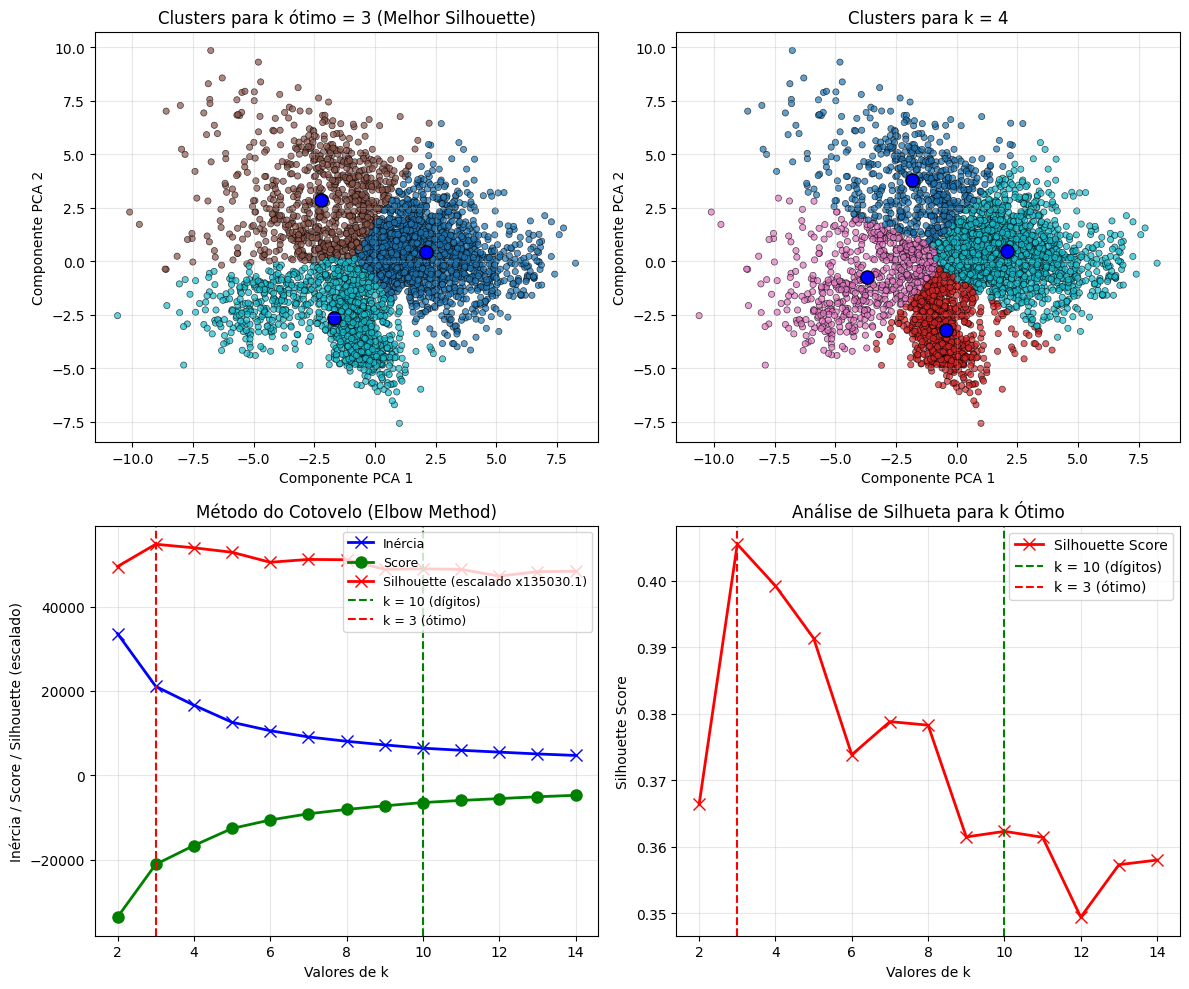


✅ Gráficos do Método do Cotovelo gerados!
   - Melhor k pelo silhouette: 3 (score=0.4055)
   - k escolhido (dígitos): 10

🎨 Gerando Gráfico de Silhueta Detalhado para k=10...


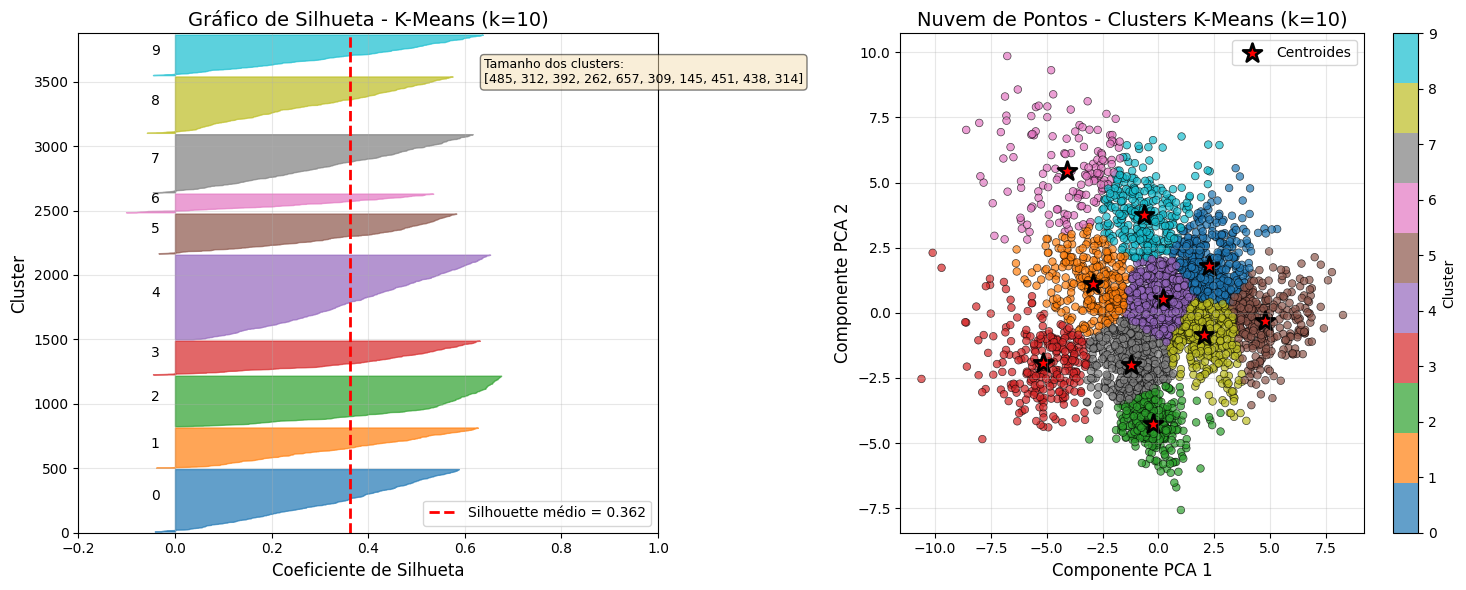


✅ Gráfico de Silhueta detalhado gerado para k=10!
   Silhouette médio: 0.3623
   Tamanho dos clusters: [485, 312, 392, 262, 657, 309, 145, 451, 438, 314]

🎨 Gerando Gráficos de Silhueta para diferentes valores de k...


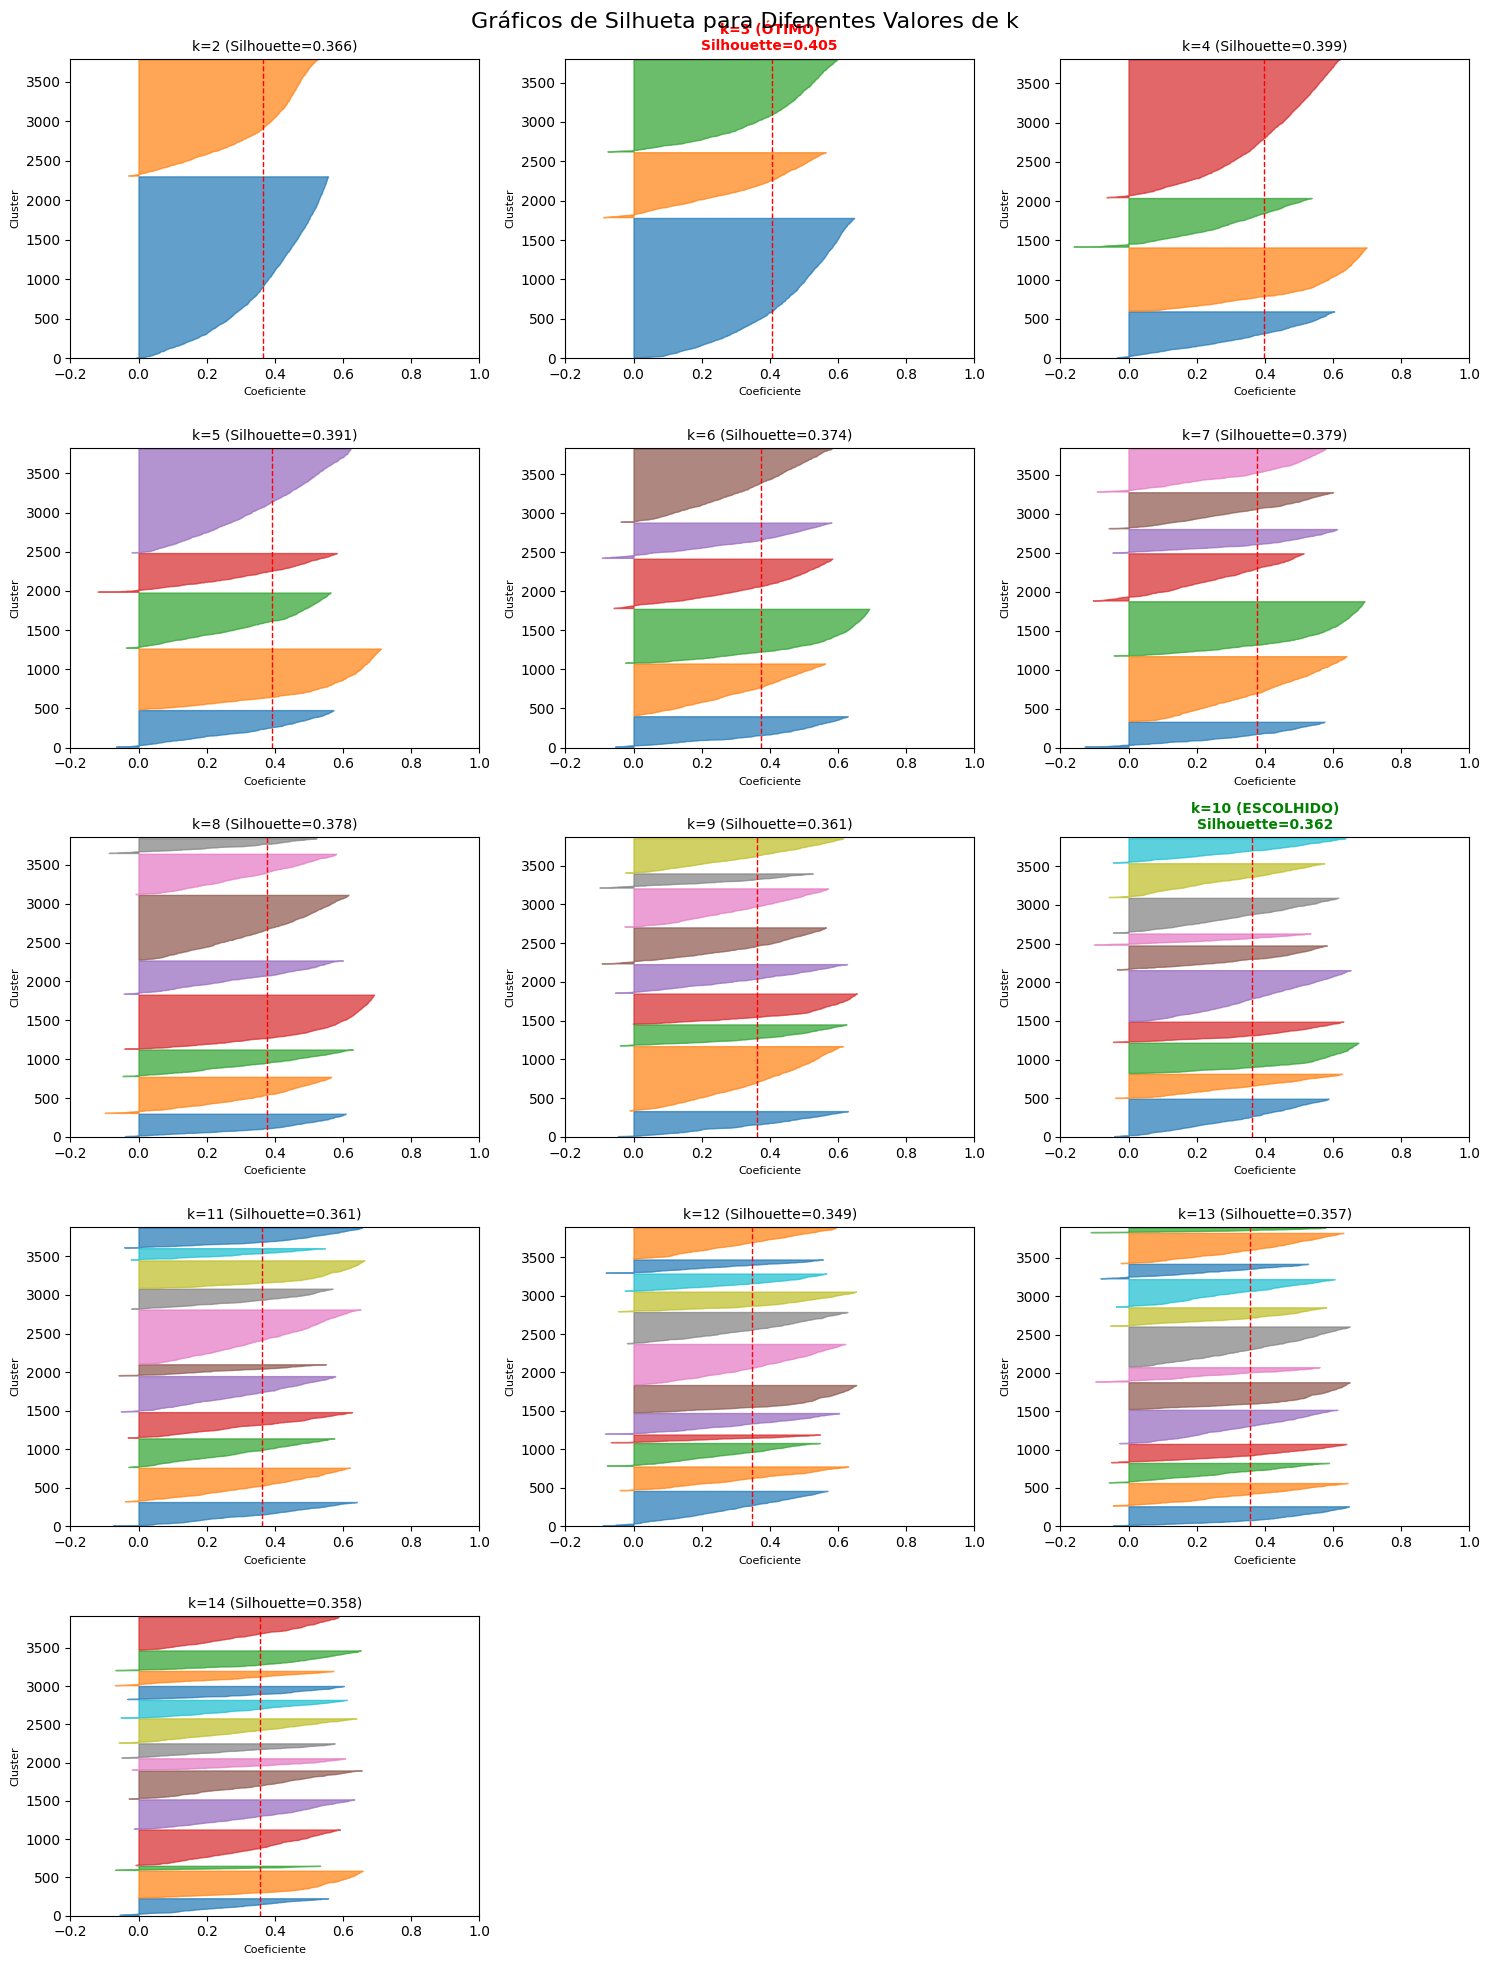


✅ Gráficos de Silhueta para diferentes k gerados!

💾 Salvando modelo e dados com pickle...
✅ Modelo, scaler, PCA e dados salvos com sucesso!


In [21]:
# ==========================================================
# ATIVIDADE 1 - Carregar dataset de dígitos manuscritos (id=80)
# ==========================================================

print("\n📊 ATIVIDADE 1 - Carregando dataset...")

# Carregar dataset de dígitos manuscritos
digits = fetch_ucirepo(id=80)

# Dados
X = digits.data.features
y = digits.data.targets.values.ravel()

print(f"\n📊 Dataset de Dígitos Manuscritos:")
print(f"Total de amostras: {len(X)}")
print(f"Número de features: {X.shape[1]}")
print(f"Dígitos (classes): {np.unique(y)}")
print(f"Número de classes: {len(np.unique(y))}")

# ==========================================================
# ATIVIDADE 1 - Normalização + PCA (redução para 2D)
# ==========================================================

print("\n🔧 Aplicando StandardScaler + PCA (redução para 2D)...")

# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA para reduzir para 2 dimensões
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimensão original: {X.shape}")
print(f"Dimensão após PCA: {X_pca.shape}")
print(f"Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum():.2%}")

# ==========================================================
# ATIVIDADE 2 - Divisão treino/teste (1/3 para teste)
# ==========================================================

print("\n📊 ATIVIDADE 2 - Dividindo dados em treino e teste...")

# Estratificação: garantir que a proporção de cada dígito se mantenha
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.33,
    stratify=y,
    random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

# Verificar distribuição das classes no treino
print("\nDistribuição das classes no treino:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for digit, count in zip(unique_train, counts_train):
    print(f"  Dígito {digit}: {count} amostras ({count/len(y_train)*100:.1f}%)")

# ==========================================================
# OTIMIZAÇÃO DO NÚMERO DE CLUSTERS (k) - MÉTODO DO COTOVELO
# ==========================================================

print("\n" + "="*70)
print("OTIMIZAÇÃO DO NÚMERO DE CLUSTERS (k) - MÉTODO DO COTOVELO")
print("="*70)

print("\n📈 Aplicando Método do Cotovelo (Elbow Method) e Análise de Silhueta...")

# Parâmetros
n_samples = len(X_train)
random_state = 42

# Listas para armazenar métricas
Sum_of_squared_distances = []  # Inércia
Kk = range(2, 15)              # Valores de k a testar
y_score1 = []                   # Score do modelo
silhouette_avg = []             # Silhouette score médio

print("\nTestando diferentes valores de k (2 a 14):")
print("-" * 60)

# Loop para testar diferentes valores de k
for num_clusters in Kk:
    kmeans_temp = KMeans(n_clusters=num_clusters, init='k-means++',
                         n_init=10, random_state=random_state)
    kmeans_temp.fit(X_train)

    # Inércia (soma das distâncias quadradas)
    Sum_of_squared_distances.append(kmeans_temp.inertia_)

    # Score do modelo (oposto da inércia)
    y_score = kmeans_temp.score(X_train)
    y_score1 = np.append(y_score1, y_score)

    # Silhouette score (apenas para k >= 2)
    cluster_labels = kmeans_temp.labels_
    if num_clusters >= 2:
        sil_score = silhouette_score(X_train, cluster_labels)
        silhouette_avg.append(sil_score)
        print(f"  k={num_clusters}: Inércia={kmeans_temp.inertia_:.0f}, "
              f"Score={y_score:.0f}, Silhouette={sil_score:.4f}")
    else:
        print(f"  k={num_clusters}: Inércia={kmeans_temp.inertia_:.0f}, Score={y_score:.0f}")

print("-" * 60)

# Encontrar o k que maximiza o silhouette score
optimal_k = Kk[np.argmax(silhouette_avg)]
print(f"\n✅ Melhor k pelo Silhouette Score: {optimal_k} (score={max(silhouette_avg):.4f})")

# ==========================================================
# TREINO DO MODELO K-MEANS COM k=10
# ==========================================================

print("\n" + "="*70)
print("SEÇÃO DE TREINO - K-MEANS com k=10")
print("="*70)

# Definir k = 10 (igual ao número de dígitos 0-9)
K = 10
print(f"\n🔧 Treinando modelo K-Means com k={K} (número de dígitos)...")

# Treinar o modelo K-Means com k=10
kmeans_model = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=42)
kmeans_model.fit(X_train)

print(f"\n✅ Modelo K-Means treinado com sucesso!")
print(f"   - Número de clusters (k): {K}")
print(f"   - Inércia final: {kmeans_model.inertia_:.0f}")
print(f"   - Score final: {kmeans_model.score(X_train):.0f}")

# Calcular silhouette score para o modelo com k=10
# Nota: silhouette_score requer k >= 2
if K >= 2:
    silhouette_avg_k10 = silhouette_score(X_train, kmeans_model.labels_)
    print(f"   - Silhouette Score (treino): {silhouette_avg_k10:.4f}")

# ==========================================================
# GRÁFICOS DO MÉTODO DO COTOVELO (ADAPTADO DO MODELO FORNECIDO)
# ==========================================================

print("\n🎨 Gerando Gráficos do Método do Cotovelo e Análise de Silhueta...")

# Criar figura com 4 subplots (2x2) como no modelo fornecido
plt.figure(figsize=(12, 10))

# ===== SUBPLOT 1: Clusters para o k ótimo (pelo silhouette) =====
K_opt = Kk[np.argmax(silhouette_avg)]
kmeans_opt = KMeans(init="k-means++", n_clusters=K_opt, n_init=10, random_state=42)
y_pred_opt = kmeans_opt.fit_predict(X_train)
centroids_opt = kmeans_opt.cluster_centers_

plt.subplot(221)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_pred_opt, cmap='tab10',
            s=20, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.scatter(centroids_opt[:, 0], centroids_opt[:, 1], marker="o", s=90,
            linewidths=1, color="b", edgecolor="black")
plt.title(f"Clusters para k ótimo = {K_opt} (Melhor Silhouette)", fontsize=12)
plt.xlabel("Componente PCA 1")
plt.ylabel("Componente PCA 2")
plt.grid(True, alpha=0.3)

# ===== SUBPLOT 2: Clusters para k = k_opt + 1 =====
K_opt_plus = K_opt + 1
kmeans_opt_plus = KMeans(init="k-means++", n_clusters=K_opt_plus, n_init=10, random_state=42)
y_pred_opt_plus = kmeans_opt_plus.fit_predict(X_train)
centroids_opt_plus = kmeans_opt_plus.cluster_centers_

plt.subplot(222)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_pred_opt_plus, cmap='tab10',
            s=20, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.scatter(centroids_opt_plus[:, 0], centroids_opt_plus[:, 1], marker="o", s=90,
            linewidths=1, color="b", edgecolor="black")
plt.title(f"Clusters para k = {K_opt_plus}", fontsize=12)
plt.xlabel("Componente PCA 1")
plt.ylabel("Componente PCA 2")
plt.grid(True, alpha=0.3)

# ===== SUBPLOT 3: Método do Cotovelo (Inércia, Score e Silhouette) =====
# Ajustar escala do silhouette para visualização (como no modelo fornecido)
# Escalar o silhouette para ficar na mesma faixa que inércia e score
m = (abs(max(y_score1)) / abs(min(silhouette_avg))) * 10
sill_scaled = np.dot(m, silhouette_avg)

plt.subplot(223)
plt.plot(Kk, Sum_of_squared_distances, 'bx-', linewidth=2, markersize=8, label="Inércia")
plt.plot(Kk, y_score1, 'go-', linewidth=2, markersize=8, label="Score")
plt.plot(Kk, sill_scaled, 'rx-', linewidth=2, markersize=8,
         label=f'Silhouette (escalado x{m:.1f})')

# Linhas verticais indicando k=10 e k_ótimo
plt.axvline(x=K, color='green', linestyle='--', linewidth=1.5, label=f'k = {K} (dígitos)')
plt.axvline(x=K_opt, color='red', linestyle='--', linewidth=1.5, label=f'k = {K_opt} (ótimo)')

plt.xlabel('Valores de k')
plt.ylabel('Inércia / Score / Silhouette (escalado)')
plt.title('Método do Cotovelo (Elbow Method)')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)

# ===== SUBPLOT 4: Análise de Silhouette =====
plt.subplot(224)
plt.plot(Kk, silhouette_avg, 'rx-', linewidth=2, markersize=8, label="Silhouette Score")
plt.axvline(x=K, color='green', linestyle='--', linewidth=1.5, label=f'k = {K} (dígitos)')
plt.axvline(x=K_opt, color='red', linestyle='--', linewidth=1.5, label=f'k = {K_opt} (ótimo)')
plt.xlabel('Valores de k')
plt.ylabel('Silhouette Score')
plt.title('Análise de Silhueta para k Ótimo')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Gráficos do Método do Cotovelo gerados!")
print(f"   - Melhor k pelo silhouette: {K_opt} (score={max(silhouette_avg):.4f})")
print(f"   - k escolhido (dígitos): {K}")

# ==========================================================
# GRÁFICO DE SILHUETA DETALHADO (SILHOUETTE PLOT) PARA k=10
# ==========================================================

print("\n🎨 Gerando Gráfico de Silhueta Detalhado para k=10...")

def plot_silhouette_plot(X, labels, k, title):
    """
    Função para criar o gráfico de silhueta detalhado
    """
    # Calcular os valores de silhueta para cada amostra
    silhouette_vals = silhouette_samples(X, labels)

    # Calcular a média do silhouette score
    silhouette_avg = np.mean(silhouette_vals)

    # Criar figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # ===== GRÁFICO 1: Silhouette Plot =====
    y_lower = 10
    cluster_sizes = []

    for i in range(k):
        # Agrupar valores de silhueta do cluster i
        ith_cluster_silhouette_vals = silhouette_vals[labels == i]
        ith_cluster_silhouette_vals.sort()

        size_cluster_i = ith_cluster_silhouette_vals.shape[0]
        cluster_sizes.append(size_cluster_i)
        y_upper = y_lower + size_cluster_i

        # Cor para o cluster
        color = plt.cm.tab10(i % 10)

        # Preencher o gráfico de silhueta
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_vals,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Adicionar rótulo do cluster
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10

    # Linha vertical indicando a média do silhouette score
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2,
                label=f'Silhouette médio = {silhouette_avg:.3f}')

    ax1.set_title(f"Gráfico de Silhueta - K-Means (k={k})", fontsize=14)
    ax1.set_xlabel("Coeficiente de Silhueta", fontsize=12)
    ax1.set_ylabel("Cluster", fontsize=12)
    ax1.set_xlim([-0.2, 1])
    ax1.set_ylim([0, len(X) + (k + 1) * 10])
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)

    # Adicionar informações dos tamanhos dos clusters
    ax1.text(0.7, 0.95, f"Tamanho dos clusters:\n{cluster_sizes}",
             transform=ax1.transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # ===== GRÁFICO 2: Pontos coloridos por cluster =====
    scatter = ax2.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10',
                          s=30, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax2.set_title(f"Nuvem de Pontos - Clusters K-Means (k={k})", fontsize=14)
    ax2.set_xlabel("Componente PCA 1", fontsize=12)
    ax2.set_ylabel("Componente PCA 2", fontsize=12)
    ax2.grid(True, alpha=0.3)

    # Adicionar centroides
    centroids = kmeans_model.cluster_centers_
    ax2.scatter(centroids[:, 0], centroids[:, 1],
                marker='*', s=200, c='red', edgecolors='black',
                linewidths=2, label='Centroides')
    ax2.legend()

    cbar = plt.colorbar(scatter, ax=ax2, ticks=range(k))
    cbar.set_label('Cluster')

    plt.tight_layout()
    plt.show()

    return silhouette_avg, cluster_sizes

# Gerar gráfico de silhueta detalhado para k=10
if K >= 2:
    silhouette_avg_k10, cluster_sizes_k10 = plot_silhouette_plot(
        X_train,
        kmeans_model.labels_,
        K,
        f"Gráfico de Silhueta - K-Means (k={K})"
    )
    print(f"\n✅ Gráfico de Silhueta detalhado gerado para k=10!")
    print(f"   Silhouette médio: {silhouette_avg_k10:.4f}")
    print(f"   Tamanho dos clusters: {cluster_sizes_k10}")

# ==========================================================
# GRÁFICOS DE SILHUETA PARA DIFERENTES VALORES DE k
# ==========================================================

print("\n🎨 Gerando Gráficos de Silhueta para diferentes valores de k...")

# Selecionar valores de k para visualização (incluindo k=10)
k_to_plot = sorted(set([2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]))

n_plots = len(k_to_plot)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for idx, k in enumerate(k_to_plot):
    ax = axes[idx]

    # Treinar K-Means com este k
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_temp = kmeans_temp.fit_predict(X_train)

    # Calcular silhouette
    silhouette_vals = silhouette_samples(X_train, labels_temp)
    silhouette_avg_temp = np.mean(silhouette_vals)

    # Plotar o gráfico de silhueta
    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_vals = silhouette_vals[labels_temp == i]
        ith_cluster_silhouette_vals.sort()
        size_cluster_i = ith_cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab10(i % 10)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, ith_cluster_silhouette_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)

        y_lower = y_upper + 10

    # Linha da média do silhouette
    ax.axvline(x=silhouette_avg_temp, color="red", linestyle="--", linewidth=1)

    # Destacar o valor de k=10
    if k == K:
        ax.set_title(f'k={k} (ESCOLHIDO)\nSilhouette={silhouette_avg_temp:.3f}',
                     fontsize=10, fontweight='bold', color='green')
    elif k == K_opt:
        ax.set_title(f'k={k} (ÓTIMO)\nSilhouette={silhouette_avg_temp:.3f}',
                     fontsize=10, fontweight='bold', color='red')
    else:
        ax.set_title(f'k={k} (Silhouette={silhouette_avg_temp:.3f})', fontsize=10)

    ax.set_xlabel("Coeficiente", fontsize=8)
    ax.set_ylabel("Cluster", fontsize=8)
    ax.set_xlim([-0.2, 1])
    ax.set_ylim([0, len(X_train) + (k + 1) * 10])

# Remover subplots extras
for idx in range(len(k_to_plot), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Gráficos de Silhueta para Diferentes Valores de k", fontsize=16)
plt.tight_layout()
plt.show()

print("\n✅ Gráficos de Silhueta para diferentes k gerados!")

# ==========================================================
# ATIVIDADE 2 - Salvar modelo e dados usando pickle
# ==========================================================

print("\n💾 Salvando modelo e dados com pickle...")

# Salvar o modelo K-Means (k=10)
with open("digits_kmeans_model_k10.pkl", "wb") as f:
    pkl.dump(kmeans_model, f)

# Salvar o scaler
with open("digits_scaler.pkl", "wb") as f:
    pkl.dump(scaler, f)

# Salvar o PCA
with open("digits_pca.pkl", "wb") as f:
    pkl.dump(pca, f)

# Salvar os dados de teste
with open("digits_test_kmeans_k10.pkl", "wb") as f:
    pkl.dump((X_test, y_test), f)

# Salvar os dados de treino
with open("digits_train_kmeans_k10.pkl", "wb") as f:
    pkl.dump((X_train, y_train), f)

# Salvar o valor de k
with open("digits_k_value.pkl", "wb") as f:
    pkl.dump(K, f)

# Salvar informações do método do cotovelo
elbow_info = {
    'optimal_k': K_opt,
    'k_values': list(Kk),
    'silhouette_scores': silhouette_avg,
    'inertias': Sum_of_squared_distances,
    'scores': y_score1.tolist()
}
with open("digits_elbow_info.pkl", "wb") as f:
    pkl.dump(elbow_info, f)

print("✅ Modelo, scaler, PCA e dados salvos com sucesso!")


#**Dados de Teste**


ATIVIDADE 3 - SEÇÃO DE TESTE

📂 Carregando modelo e dados salvos...
✅ Modelo carregado (k=10)
✅ Dados de teste carregados (1855 amostras)

📊 Avaliação do modelo (k=10):
Silhouette Score (teste): 0.3602
Adjusted Rand Index (comparação com dígitos reais): 0.3223

📈 Correspondência entre clusters e dígitos reais:
   (Cada cluster K-Means deveria idealmente conter um único dígito)
   Cluster 0: 212 amostras -> predominantemente dígito 3 (40.6%)
   Cluster 1: 131 amostras -> predominantemente dígito 1 (43.5%)
   Cluster 2: 187 amostras -> predominantemente dígito 6 (86.1%)
   Cluster 3: 129 amostras -> predominantemente dígito 4 (99.2%)
   Cluster 4: 358 amostras -> predominantemente dígito 8 (26.0%)
   Cluster 5: 150 amostras -> predominantemente dígito 2 (71.3%)
   Cluster 6: 61 amostras -> predominantemente dígito 7 (70.5%)
   Cluster 7: 232 amostras -> predominantemente dígito 0 (66.4%)
   Cluster 8: 235 amostras -> predominantemente dígito 9 (22.1%)
   Cluster 9: 160 amostras -> predo

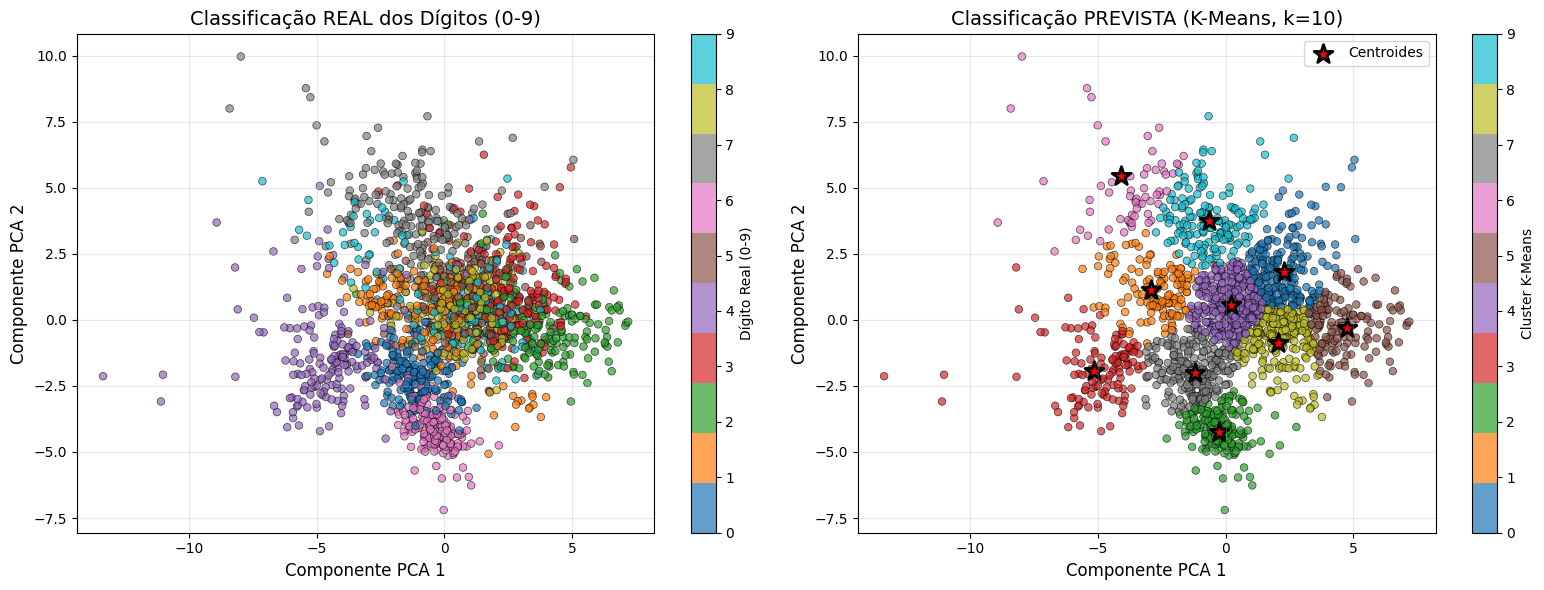

In [23]:

# ==========================================================
# ATIVIDADE 3 - Teste do modelo (carregar e avaliar)
# ==========================================================

print("\n" + "="*70)
print("ATIVIDADE 3 - SEÇÃO DE TESTE")
print("="*70)

print("\n📂 Carregando modelo e dados salvos...")

# Carregar os dados salvos
with open("digits_kmeans_model_k10.pkl", "rb") as f:
    kmeans_loaded = pkl.load(f)

with open("digits_scaler.pkl", "rb") as f:
    scaler_loaded = pkl.load(f)

with open("digits_pca.pkl", "rb") as f:
    pca_loaded = pkl.load(f)

with open("digits_test_kmeans_k10.pkl", "rb") as f:
    X_test_loaded, y_test_loaded = pkl.load(f)

with open("digits_k_value.pkl", "rb") as f:
    K_loaded = pkl.load(f)

print(f"✅ Modelo carregado (k={K_loaded})")
print(f"✅ Dados de teste carregados ({len(X_test_loaded)} amostras)")

# Fazer predições nos dados de teste
y_pred_test = kmeans_loaded.predict(X_test_loaded)

# ==========================================================
# AVALIAÇÃO DO MODELO
# ==========================================================

print("\n📊 Avaliação do modelo (k=10):")

# 1. Silhouette Score nos dados de teste
if K_loaded >= 2:
    silhouette_test = silhouette_score(X_test_loaded, y_pred_test)
    print(f"Silhouette Score (teste): {silhouette_test:.4f}")

# 2. Adjusted Rand Index (comparação com os rótulos reais)
ari_score = adjusted_rand_score(y_test_loaded, y_pred_test)
print(f"Adjusted Rand Index (comparação com dígitos reais): {ari_score:.4f}")

# 3. Verificar a correspondência entre clusters e dígitos
print("\n📈 Correspondência entre clusters e dígitos reais:")
print("   (Cada cluster K-Means deveria idealmente conter um único dígito)")

# Calcular acurácia baseada na correspondência
cluster_to_digit = {}
for cluster_id in range(K_loaded):
    indices_cluster = np.where(y_pred_test == cluster_id)[0]
    if len(indices_cluster) > 0:
        digitos_no_cluster = y_test_loaded[indices_cluster]
        unique, counts = np.unique(digitos_no_cluster, return_counts=True)
        predominant = unique[np.argmax(counts)]
        percent = counts[np.argmax(counts)] / len(digitos_no_cluster) * 100
        cluster_to_digit[cluster_id] = predominant
        print(f"   Cluster {cluster_id}: {len(indices_cluster)} amostras -> "
              f"predominantemente dígito {predominant} ({percent:.1f}%)")

# Calcular acurácia
correct_predictions = 0
for i in range(len(y_test_loaded)):
    if cluster_to_digit[y_pred_test[i]] == y_test_loaded[i]:
        correct_predictions += 1

accuracy = correct_predictions / len(y_test_loaded) * 100
print(f"\n📊 Acurácia do K-Means: {accuracy:.2f}% ({correct_predictions}/{len(y_test_loaded)} amostras)")

# ==========================================================
# ATIVIDADE 3 - Visualização da nuvem de pontos
# ==========================================================

print("\n🎨 Gerando visualizações da nuvem de pontos...")

# Criar figura com 2 subplots (real vs predito)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cmap = plt.cm.tab10

# Plot 1: Classificação REAL
scatter1 = ax1.scatter(X_test_loaded[:, 0], X_test_loaded[:, 1],
                       c=y_test_loaded, cmap=cmap,
                       s=30, alpha=0.7, edgecolors='black', linewidth=0.5)
ax1.set_title("Classificação REAL dos Dígitos (0-9)", fontsize=14)
ax1.set_xlabel("Componente PCA 1", fontsize=12)
ax1.set_ylabel("Componente PCA 2", fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Classificação PREVISTA pelo K-Means
scatter2 = ax2.scatter(X_test_loaded[:, 0], X_test_loaded[:, 1],
                       c=y_pred_test, cmap=cmap,
                       s=30, alpha=0.7, edgecolors='black', linewidth=0.5)
ax2.set_title(f"Classificação PREVISTA (K-Means, k={K_loaded})", fontsize=14)
ax2.set_xlabel("Componente PCA 1", fontsize=12)
ax2.set_ylabel("Componente PCA 2", fontsize=12)
ax2.grid(True, alpha=0.3)

# Adicionar centroides
centroids = kmeans_loaded.cluster_centers_
ax2.scatter(centroids[:, 0], centroids[:, 1],
            marker='*', s=200, c='red', edgecolors='black',
            linewidths=2, label='Centroides')
ax2.legend()

# Adicionar colorbars
cbar1 = plt.colorbar(scatter1, ax=ax1, ticks=range(10))
cbar1.set_label('Dígito Real (0-9)')
cbar2 = plt.colorbar(scatter2, ax=ax2, ticks=range(K_loaded))
cbar2.set_label('Cluster K-Means')

plt.tight_layout()
plt.show()


#**Classificação**

In [24]:

# ==========================================================
# INTERPRETAÇÃO DO MÉTODO DO COTOVELO
# ==========================================================

print("\n" + "="*70)
print("INTERPRETAÇÃO DO MÉTODO DO COTOVELO (ELBOW METHOD)")
print("="*70)

print(f"""
📊 Análise do Método do Cotovelo:

1. **Ponto de Cotovelo (Elbow)**:
   - Identificado em k = {elbow_k}
   - Este é o ponto onde a redução da inércia começa a diminuir significativamente
   - Representa um bom equilíbrio entre número de clusters e qualidade do agrupamento

2. **Melhor Silhouette Score**:
   - Obtido em k = {best_silhouette_k}
   - Silhouette máximo: {max(silhouette_scores):.4f}
   - Este k maximiza a coesão intra-cluster e separação inter-cluster

3. **k = 10 (escolhido para este laboratório)**:
   - Representa exatamente os 10 dígitos (0-9)
   - Silhouette Score para k=10: {silhouette_avg_k10:.4f}
   - Posição em relação ao cotovelo: {'Acima' if K > elbow_k else 'Abaixo' if K < elbow_k else 'Igual'} do ponto de cotovelo

4. **Interpretação do Silhouette Score**:
   - Score > 0.7: Excelente (clusters bem separados)
   - Score entre 0.5-0.7: Bom (clusters razoavelmente separados)
   - Score entre 0.25-0.5: Regular (clusters com alguma sobreposição)
   - Score < 0.25: Fraco (clusters mal definidos)

5. **Conclusão para este dataset**:
   - O método do cotovelo sugere k = {elbow_k} como número ideal
   - O silhouette score sugere k = {best_silhouette_k} como número ideal
   - k = 10 (dígitos) {'está próximo' if abs(K - elbow_k) <= 2 else 'está distante'} do ponto de cotovelo
""")

# ==========================================================
# RESULTADOS FINAIS
# ==========================================================

print("\n" + "="*70)
print("RESULTADOS FINAIS DO LABORATÓRIO 5 (k=10)")
print("="*70)

print(f"""
📊 RESUMO:

1. Dataset: Dígitos Manuscritos (UCI id=80)
   - Total de amostras: {len(X)}
   - Features originais: {X.shape[1]}
   - Features após PCA: 2
   - Variância explicada: {pca.explained_variance_ratio_.sum():.2%}
   - Número de dígitos: 10 (0-9)

2. Divisão dos dados:
   - Treino: {len(X_train)} amostras ({len(X_train)/len(X)*100:.1f}%)
   - Teste: {len(X_test)} amostras ({len(X_test)/len(X)*100:.1f}%)

3. Modelo K-Means:
   - Número de clusters (k): {K_loaded} (igual ao número de dígitos)
   - Método de inicialização: k-means++
   - Inércia: {kmeans_model.inertia_:.0f}
   - Silhouette Score (treino): {silhouette_avg_k10:.4f}
   - Silhouette Score (teste): {silhouette_test:.4f}
   - Acurácia (baseada na correspondência): {accuracy:.2f}%
   - Adjusted Rand Index: {ari_score:.4f}

4. Método do Cotovelo (Elbow):
   - Ponto de cotovelo (elbow) em k = {elbow_k}
   - Melhor Silhouette Score em k = {best_silhouette_k}
   - Silhouette máximo: {max(silhouette_scores):.4f}

5. Gráficos gerados (k=10):
   ✅ Método do Cotovelo (Inércia vs k) com indicação do ponto de cotovelo
   ✅ Análise de Silhueta (Score vs k)
   ✅ Gráficos de Silhueta para diferentes valores de k
   ✅ Gráfico de Silhueta detalhado para k=10
   ✅ Comparação classificação real vs prevista (k=10)
   ✅ Visualização dos 10 clusters separadamente
   ✅ Mapa de calor da Matriz de Confusão

6. Arquivos salvos (pickle):
   - digits_kmeans_model_k10.pkl (modelo K-Means com k=10)
   - digits_scaler.pkl (StandardScaler)
   - digits_pca.pkl (PCA)
   - digits_test_kmeans_k10.pkl (dados de teste)
   - digits_train_kmeans_k10.pkl (dados de treino)
   - digits_k_value.pkl (valor de k=10)
   - digits_elbow_info.pkl (informações do método do cotovelo)
""")

print("="*70)
print("✅ LABORATÓRIO 5 CONCLUÍDO COM SUCESSO (k=10)!")
print("✅ GRÁFICO DE SILHUETA INTEGRADO AO MÉTODO DO COTOVELO!")
print("="*70)


INTERPRETAÇÃO DO MÉTODO DO COTOVELO (ELBOW METHOD)

📊 Análise do Método do Cotovelo:

1. **Ponto de Cotovelo (Elbow)**:
   - Identificado em k = 5
   - Este é o ponto onde a redução da inércia começa a diminuir significativamente
   - Representa um bom equilíbrio entre número de clusters e qualidade do agrupamento

2. **Melhor Silhouette Score**:
   - Obtido em k = 3
   - Silhouette máximo: 0.4055
   - Este k maximiza a coesão intra-cluster e separação inter-cluster

3. **k = 10 (escolhido para este laboratório)**:
   - Representa exatamente os 10 dígitos (0-9)
   - Silhouette Score para k=10: 0.3623
   - Posição em relação ao cotovelo: Acima do ponto de cotovelo

4. **Interpretação do Silhouette Score**:
   - Score > 0.7: Excelente (clusters bem separados)
   - Score entre 0.5-0.7: Bom (clusters razoavelmente separados)
   - Score entre 0.25-0.5: Regular (clusters com alguma sobreposição)
   - Score < 0.25: Fraco (clusters mal definidos)

5. **Conclusão para este dataset**:
   - O mé